# Competition-submission inference viewer

For each test fragment (+ the w055 holdout), this builds one **gargantuan full-size** figure with **4 panels**:

| raw inferno heatmap (depths 4–28) | inferno heatmap + TTA hallucination mitigation | composite (fiber-visibility) | composite (again, for text overlay) |

- Matches the current two-stage test path: `v15_twostage_*`, tile 16, **depth 24 ingested at once** (slices 4–28, no depth-max — the two-stage model fuses depth internally).
- **Composite** = fiber-visibility render straight from the zarr (VC3D-style max over an ~8-layer surface window, raw 0–255), **cached** as PNG (expensive on big fragments).
- **TTA** = dihedral test-time augmentation (average over flips/rotations) to suppress hallucinations.
- Layout auto-flips: tall region → 1×4 (side by side); wide region → 4×1 (stacked).
- A mm **scale bar** is drawn on the composite panels (9.362 µm/pixel).
- Each figure is saved **full-size** as JPG to `./output/<fragment>.jpg` (no downscaling) and previewed at ~quarter resolution in the cell.
- **`DRY_RUN`**: no model load / no inference — every panel shows the **composite** (generated/cached as needed), so you can vet the fiber render before running the model.

**Set `DRY_RUN` and `MODEL_PATH` in the CONFIG cell, then Run All.**

In [1]:
# ============================ CONFIG — edit these ============================
DRY_RUN    = False      # True = masks-only preview (NO model load, NO inference); still saves all figures
MODEL_PATH = r"models/model_epoch_8.pth"  # best checkpoint (update after training)
ARCH       = "v15_twostage_wide_zgrad_ctx"   # must match the checkpoint arch (use the *_ctx variant when CONTEXT_SIZE>TILE_SIZE)
TILE_SIZE  = 16      # label/output tile size (the context model still predicts on 16px tiles)
CONTEXT_SIZE = 32    # input crop centered on each tile: 0 or ==TILE_SIZE -> plain model; 32 -> context
                     # model (REQUIRES the *_ctx arch above). must match how the checkpoint was trained.
DEPTH      = 24      # slices ingested at once (two-stage fuses depth internally; no depth-max)
D_START    = 4       # absolute depth window start (model input)
D_END      = 28      # absolute depth window end (model input; D_END - D_START == DEPTH)

TTA                 = True         # hallucination mitigation: dihedral test-time augmentation
# --- composite (fiber-visibility) render, matched to VC3D's Compositing.hpp ---
COMPOSITE_METHOD    = "maxproj"    # VC3D default is a MAX filter over a limited surface window
COMPOSITE_D0        = 10           # window start slice (VC3D samples ~8 layers around the surface,
COMPOSITE_D1        = 18           #   NOT all 28 — deep layers add a dark band VC3D never shows)
COMPOSITE_DISPLAY   = "raw"        # "raw" = direct 0-255 (VC3D's linear volume window, honest low
                                   #   contrast). "stretch" = robust 1-99 in-mask stretch (punchier)
COMPOSITE_CLAHE     = False        # CLAHE darkens/grains a masked image; off matches VC3D
GENERATE_COMPOSITES = False        # True = force clean regen of composites (overwrite the cache on disk)
VOXEL_UM            = 9.362        # microns per pixel at full resolution (drives the 1 cm scale bar)
DISPLAY_SCALE       = 0.25         # matplotlib preview scale; SAVED files are always full size
MASK_CROP_MARGIN    = 32           # px margin kept around the mask bounding box when cropping
PAD_PX              = 24           # white padding around each panel (visual separation)

OUTPUT_DIR        = "output"
COMPOSITE_CACHE   = "output/composite_cache"   # composites cached inside the output folder

# 5 test fragments + 1 holdout. name (output filename) -> zarr id (ves_zarrs2/<id>.zarr + masks/<id>.png)
FRAGMENTS = {
    "auto_grown_20260716083545":   20260716083545,   # PHerc0813 test
    "auto_grown_20260717193517":   20260717193517,   # PHerc0211 test
    "auto_grown_20260719202304":   20260719202304,   # PHerc0211 test
    "auto_grown_20260720090842":   20260720090842,   # PHerc1203 test
    "auto_grown_20250703034159":   20250703034159,   # PHerc1447 test (51.27cm², 8.64µm src)
    "w055_holdout_20251226000000": 20251226000000,   # PHerc0139 HOLDOUT (sanity — not in training)
}
# ============================================================================

In [2]:
import os, sys, json
REPO = r"C:\Users\ChenJeff\Documents\vesuvius"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)  # so ./masks and ./ves_zarrs2 relative paths resolve

import numpy as np
import torch
import zarr
import cv2
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

from utils.config import Config
from utils.model import create_model
from utils.visualizer import predict_tiles
from utils.dataloader import _load_unified_cache

# utils.visualizer forces the non-interactive 'Agg' backend at import; restore inline
# display so the quarter-res previews render in the notebook.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPOSITE_CACHE, exist_ok=True)
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(), '| DRY_RUN', DRY_RUN)

torch 2.11.0+cu128 | cuda True | DRY_RUN False


In [3]:
# ============ COMPOSITE (fiber-visibility) — reusable fn + method playground ============
# the composite is a fiber-visibility render straight from the zarr (NOT a prediction). it
# collapses a depth window into one 2D grayscale image so text predictions can later be
# overlaid on visible papyrus fibers. expensive on big fragments -> CACHED as PNG in
# output/composite_cache/. set GENERATE_COMPOSITES=True to force clean regeneration.
#
# MATCHED TO VC3D (core/util/Compositing.hpp): it applies a MAX filter over a LIMITED window
# (~8 layers around the surface, e.g. slices 10-18), NOT all 28 — deep layers add a dark band
# VC3D never shows. display is a linear volume window mapping raw 0-255 (COMPOSITE_DISPLAY="raw"),
# NOT a per-image percentile stretch or CLAHE (those manufacture contrast that isn't in VC3D).

def _project_depth(vol, d0, d1, method):
    """memory-bounded depth projection over slices [d0, d1) of a zarr volume (one slice at a time)."""
    H, W = int(vol.shape[1]), int(vol.shape[2])
    d0, d1 = max(0, d0), min(d1, int(vol.shape[0]))
    if method == "maxproj":
        acc = np.zeros((H, W), np.float32)
        for d in range(d0, d1):
            acc = np.maximum(acc, np.asarray(vol[d]).astype(np.float32))
        return acc
    if method == "meanproj":
        acc = np.zeros((H, W), np.float64)
        for d in range(d0, d1):
            acc += np.asarray(vol[d])
        return (acc / max(d1 - d0, 1)).astype(np.float32)
    if method == "minproj":
        acc = np.full((H, W), np.inf, np.float32)
        for d in range(d0, d1):
            acc = np.minimum(acc, np.asarray(vol[d]).astype(np.float32))
        return np.where(np.isfinite(acc), acc, 0).astype(np.float32)
    if method == "stdproj":   # depth-variance highlights fiber structure
        s = np.zeros((H, W), np.float64); s2 = np.zeros((H, W), np.float64)
        for d in range(d0, d1):
            sl = np.asarray(vol[d]).astype(np.float64); s += sl; s2 += sl * sl
        n = max(d1 - d0, 1); m = s / n
        return np.sqrt(np.clip(s2 / n - m * m, 0, None)).astype(np.float32)
    if method == "midslice":
        return np.asarray(vol[(d0 + d1) // 2]).astype(np.float32)
    raise ValueError(f"unknown composite method: {method}")

def _display_map(proj, m, mode, use_clahe):
    """map a float projection to uint8 for display.
    mode='raw'     -> direct 0-255 (VC3D's linear volume window; honest, low contrast).
    mode='stretch' -> robust 1-99 pct stretch computed WITHIN the mask (punchier)."""
    if mode == "raw":
        img = np.clip(proj, 0, 255).astype(np.uint8)
    else:
        lo, hi = np.percentile(proj[m], [1, 99]) if m.any() else (float(proj.min()), float(proj.max()))
        disp = np.clip((proj - lo) / max(hi - lo, 1e-6), 0, 1)
        img = (disp * 255).astype(np.uint8)
    if use_clahe:
        img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return img * m.astype(np.uint8)   # zero outside the mask

def make_composite(scroll_id, method=None, d0=None, d1=None, use_cache=True, display=None, clahe=None):
    """return a uint8 fiber-visibility composite (2D) for a scroll, cached as PNG.
    depth window defaults to COMPOSITE_D0..COMPOSITE_D1 (VC3D's ~8-layer surface window).
    GENERATE_COMPOSITES=True forces recompute + overwrite regardless of use_cache."""
    method  = method or COMPOSITE_METHOD
    display = display or COMPOSITE_DISPLAY
    clahe   = COMPOSITE_CLAHE if clahe is None else clahe
    vol = zarr.open(os.path.join(Config().data.zarr_path, f"{scroll_id}.zarr"), mode="r")
    Z = int(vol.shape[0])
    d0 = COMPOSITE_D0 if d0 is None else d0
    d1 = (COMPOSITE_D1 if COMPOSITE_D1 is not None else Z) if d1 is None else d1
    d0, d1 = max(0, d0), min(d1, Z)
    tag = f"_{display}" + ("_clahe" if clahe else "")
    cache_p = os.path.join(COMPOSITE_CACHE, f"{scroll_id}_{method}_{d0}-{d1}{tag}.png")
    if use_cache and not GENERATE_COMPOSITES and os.path.exists(cache_p):
        return np.array(Image.open(cache_p).convert("L"))
    mpath = f"masks/{scroll_id}.png"
    mask = (np.array(Image.open(mpath).convert("L")) > 0) if os.path.exists(mpath) else None
    proj = _project_depth(vol, d0, d1, method)
    m = mask if (mask is not None and mask.shape == proj.shape) else (proj > 0)
    img = _display_map(proj, m, display, clahe)
    Image.fromarray(img).save(cache_p)
    print(f"[composite] {scroll_id} {method} d{d0}-{d1}{tag} -> {cache_p}  {img.shape}"
          f"{'  (forced regen)' if GENERATE_COMPOSITES else ''}")
    return img

# --- playground: compare projection methods on the smallest test scroll ---
# VC3D match = maxproj + raw display over the COMPOSITE_D0..D1 surface window.
# (skipped on DRY_RUN; set DRY_RUN=False to experiment, then pick settings in the CONFIG cell)
# if not DRY_RUN:
#     PLAY_ID = 20260716083545   # PHerc0813 (smallest test scroll -> cheap to recompute)
#     trials = [("maxproj", "raw"), ("maxproj", "stretch"), ("meanproj", "raw"), ("midslice", "raw")]
#     fig, axes = plt.subplots(1, len(trials), figsize=(4 * len(trials), 4))
#     for ax, (meth, disp) in zip(axes, trials):
#         img = make_composite(PLAY_ID, method=meth, display=disp, use_cache=False, clahe=False)
#         ax.imshow(img, cmap="gray")
#         ax.set_title(f"{meth} {disp}"); ax.axis("off")
#     plt.tight_layout(); plt.show()
# else:
#     print("[playground] skipped on DRY_RUN")

In [4]:
# ============ inference + reusable 1x4 figure builder ============
def build_config():
    c = Config()
    c.data.tile_size = TILE_SIZE; c.data.depth = DEPTH
    c.data.context_size = CONTEXT_SIZE   # >TILE_SIZE -> predict_tiles reads a wider input crop per tile (context model)
    c.data.d_start = D_START; c.data.d_end = D_END
    c.model.arch = ARCH
    c.device = "cuda" if torch.cuda.is_available() else "cpu"
    return c

def load_model(c):
    model, n = create_model(c)
    sd = torch.load(MODEL_PATH, map_location=c.device)
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    missing, unexpected = model.load_state_dict(sd, strict=False)
    model.eval()
    print(f"loaded {MODEL_PATH}  params={n:,} missing={len(missing)} unexpected={len(unexpected)}")
    return model

def get_norm(scroll_id, vol, mask):
    """cached norm if present (training/test scrolls); else compute memory-bounded (holdout)."""
    st = _load_unified_cache().get(str(scroll_id))
    if st and all(k in st for k in ("mean", "std", "min", "max")):
        return st["mean"], st["std"], st["min"], st["max"]
    print(f"[norm] computing for {scroll_id} (uncached)...")
    s = s2 = cnt = 0.0
    for d in range(int(vol.shape[0])):
        v = np.asarray(vol[d]).astype(np.float64)[mask > 0]
        if v.size:
            s += v.sum(); s2 += (v * v).sum(); cnt += v.size
    mean = s / max(cnt, 1); std = float(np.sqrt(max(s2 / max(cnt, 1) - mean * mean, 1e-12)))
    gmin = gmax = None
    for d in range(int(vol.shape[0])):
        v = (np.asarray(vol[d]).astype(np.float64)[mask > 0] - mean) / std
        if v.size:
            gmin = v.min() if gmin is None else min(gmin, v.min())
            gmax = v.max() if gmax is None else max(gmax, v.max())
    return mean, std, float(gmin), float(gmax)

def predict_map(model, c, scroll_id, tta, also_tta=False):
    """tile-downsampled ink-probability map over the single depth window (4-28).
    also_tta=True -> returns (raw_map, tta_map) from a SINGLE read (TTA re-augments the
    already-loaded tiles instead of re-reading the zarr)."""
    vol = zarr.open(os.path.join(c.data.zarr_path, f"{scroll_id}.zarr"), mode="r")
    mask = np.array(Image.open(f"masks/{scroll_id}.png").convert("L")) / 255.0
    H, W = mask.shape
    gm, gs, gmin, gmax = get_norm(scroll_id, vol, mask)
    T = TILE_SIZE
    coords = [(0, y, x) for y in range(0, H - T + 1, T) for x in range(0, W - T + 1, T)
              if mask[y:y+T, x:x+T].sum() > 0]
    return predict_tiles(c, model, vol, mask, coords, (0, H), (0, W),
                         D_START, f"Frag_{scroll_id}", gm, gs, gmin, gmax, tta=tta, also_tta=also_tta)

def _mask_bbox(mask_bool, margin):
    """outer bounding box of the mask (+margin), clamped to image bounds."""
    ys, xs = np.where(mask_bool)
    if ys.size == 0:
        return 0, mask_bool.shape[0], 0, mask_bool.shape[1]
    y0 = max(0, int(ys.min()) - margin); y1 = min(mask_bool.shape[0], int(ys.max()) + 1 + margin)
    x0 = max(0, int(xs.min()) - margin); x1 = min(mask_bool.shape[1], int(xs.max()) + 1 + margin)
    return y0, y1, x0, x1

def _colorize(pmap, out_hw):
    """tile-res prob map -> full-res inferno BGR; NaN (outside mask) -> gray."""
    m = np.isfinite(pmap)
    p8 = (np.clip(np.nan_to_num(pmap, nan=0.0), 0, 1) * 255).astype(np.uint8)
    bgr = cv2.applyColorMap(p8, cv2.COLORMAP_INFERNO)
    bgr[~m] = (115, 115, 115)
    return cv2.resize(bgr, (out_hw[1], out_hw[0]), interpolation=cv2.INTER_NEAREST)

def _red_scale_bar_1cm(bgr):
    """draw a RED 1 cm scale bar bottom-right; oriented along the longer axis of the panel."""
    H, W = bgr.shape[:2]
    L = int(round(10000.0 / VOXEL_UM))   # 1 cm in pixels at full res
    red = (0, 0, 255)                    # BGR
    th = max(4, min(H, W) // 250)
    pad = int(0.05 * min(H, W)) + th
    fs = 1.2
    ft = 3
    if W >= H:   # horizontally longer -> horizontal bar
        x1 = W - pad; x0 = max(0, x1 - L); y = H - pad
        cv2.rectangle(bgr, (x0, y - th), (x1, y), red, -1)
        cv2.putText(bgr, "1 cm", (x0, y - th - 12), cv2.FONT_HERSHEY_SIMPLEX, fs, red, ft, cv2.LINE_AA)
    else:        # vertically longer -> vertical bar
        y1 = H - pad; y0 = max(0, y1 - L); x = W - pad
        cv2.rectangle(bgr, (x - th, y0), (x, y1), red, -1)
        cv2.putText(bgr, "1 cm", (max(0, x - th - int(4 * fs * 22)), y0 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, red, ft, cv2.LINE_AA)
    return bgr

def _pad(panel):
    """white border around a panel for visual separation."""
    return cv2.copyMakeBorder(panel, PAD_PX, PAD_PX, PAD_PX, PAD_PX,
                              cv2.BORDER_CONSTANT, value=(255, 255, 255))

def _run_name():
    """derive a per-run folder name from the checkpoint filename (drops _final/.pth)."""
    base = MODEL_PATH.replace("\\", "/").rstrip("/").split("/")[-1]
    return base.replace("_final.pth", "").replace(".pth", "") or "run"

def render_fragment(name, scroll_id, model=None, c=None):
    """build + save + preview the 4-panel figure for one fragment, cropped to the mask bbox.
    panels: [raw heatmap | TTA heatmap | composite | overlay(composite +1cm red bar)].
    DRY_RUN -> the COMPOSITE (fiber-visibility) render x4 (generated/cached as needed)."""
    mask_full = np.array(Image.open(f"masks/{scroll_id}.png").convert("L"))
    y0, y1, x0, x1 = _mask_bbox(mask_full > 0, MASK_CROP_MARGIN)
    Hc, Wc = y1 - y0, x1 - x0
    if DRY_RUN or model is None:
        # DRY_RUN previews the composite (fiber-visibility) x4, NOT the bare mask.
        comp = make_composite(scroll_id)
        if comp.shape != mask_full.shape:
            comp = cv2.resize(comp, (mask_full.shape[1], mask_full.shape[0]), interpolation=cv2.INTER_AREA)
        base = cv2.cvtColor(comp, cv2.COLOR_GRAY2BGR)[y0:y1, x0:x1]
        panels = [base.copy() for _ in range(4)]
        kind = "DRY composite x4"
    else:
        H, W = mask_full.shape
        # single read -> both raw + TTA maps (also_tta) when TTA is on; else one plain read
        if TTA:
            raw, ttp = predict_map(model, c, scroll_id, tta=False, also_tta=True)
        else:
            raw = predict_map(model, c, scroll_id, tta=False); ttp = raw
        comp = make_composite(scroll_id)
        if comp.shape != (H, W):
            comp = cv2.resize(comp, (W, H), interpolation=cv2.INTER_AREA)
        p1 = _colorize(raw, (H, W))[y0:y1, x0:x1]
        p2 = _colorize(ttp, (H, W))[y0:y1, x0:x1]
        p3 = cv2.cvtColor(comp, cv2.COLOR_GRAY2BGR)[y0:y1, x0:x1]
        panels = [p1, p2, p3.copy(), p3.copy()]
        kind = " raw | TTA | composite | overlay"
    # red 1 cm scale bar on the LAST panel only (bottom-right, oriented by longer axis)
    panels[3] = _red_scale_bar_1cm(panels[3])
    # white padding around every panel, then concat (tall -> 1x4 side by side; wide -> 4x1 stacked)
    panels = [_pad(p) for p in panels]
    if Hc >= Wc:
        big = np.hstack(panels)
    else:
        big = np.vstack(panels)
    # save FULL-SIZE into a per-run subfolder under output/test_visualizations to avoid clutter
    out_dir = os.path.join(OUTPUT_DIR, "test_visualizations", _run_name())
    os.makedirs(out_dir, exist_ok=True)
    out_p = os.path.join(out_dir, f"{name}.jpg")
    cv2.imwrite(out_p, big, [cv2.IMWRITE_JPEG_QUALITY, 92])
    print(f"[saved] {out_p}  full size {big.shape[1]}x{big.shape[0]}  crop=({Hc}x{Wc})  ({kind})")
    disp = cv2.resize(big, (max(1, int(big.shape[1] * DISPLAY_SCALE)),
                            max(1, int(big.shape[0] * DISPLAY_SCALE))))
    plt.figure(figsize=(disp.shape[1] / 100, disp.shape[0] / 100))
    plt.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.title(f"{name}  [{kind}]", fontsize=8)
    plt.show()


In [5]:
# build config + load model ONCE. on DRY_RUN the model is never loaded.
C = build_config()
MODEL = None if DRY_RUN else load_model(C)
print("model:", "SKIPPED (DRY_RUN)" if MODEL is None else ARCH)

Model parameters (v15_twostage_wide_zgrad_ctx): 1,183,076
loaded models/model_epoch_8.pth  params=1,183,076 missing=0 unexpected=0
model: v15_twostage_wide_zgrad_ctx


[predict] reading 12301 tiles in 120 row-strips (Frag_20260716083545)


Predict Frag_20260716083545: 100%|██████████| 49/49 [01:39<00:00,  2.02s/it]


[saved] output\test_visualizations\model_epoch_8\auto_grown_20260716083545.jpg  full size 2223x8016  crop=(1956x2175)  ( raw | TTA | composite | overlay)


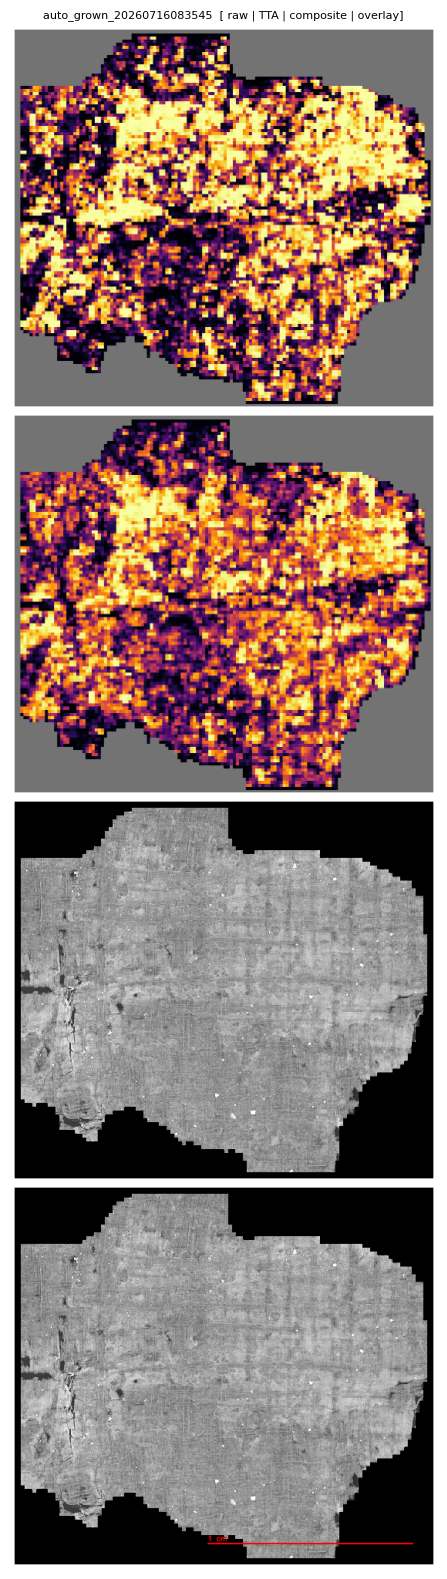

In [ ]:
# --- test fragment 1: PHerc0813 ---
# 2.98cm^2, 1892×2111
NAME = "auto_grown_20260716083545"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)

[predict] reading 25704 tiles in 448 row-strips (Frag_20260717193517)


Predict Frag_20260717193517: 100%|██████████| 101/101 [05:53<00:00,  3.50s/it]


[saved] output\test_visualizations\model_epoch_8\auto_grown_20260717193517.jpg  full size 7796x7259  crop=(7211x1901)  ( raw | TTA | composite | overlay)


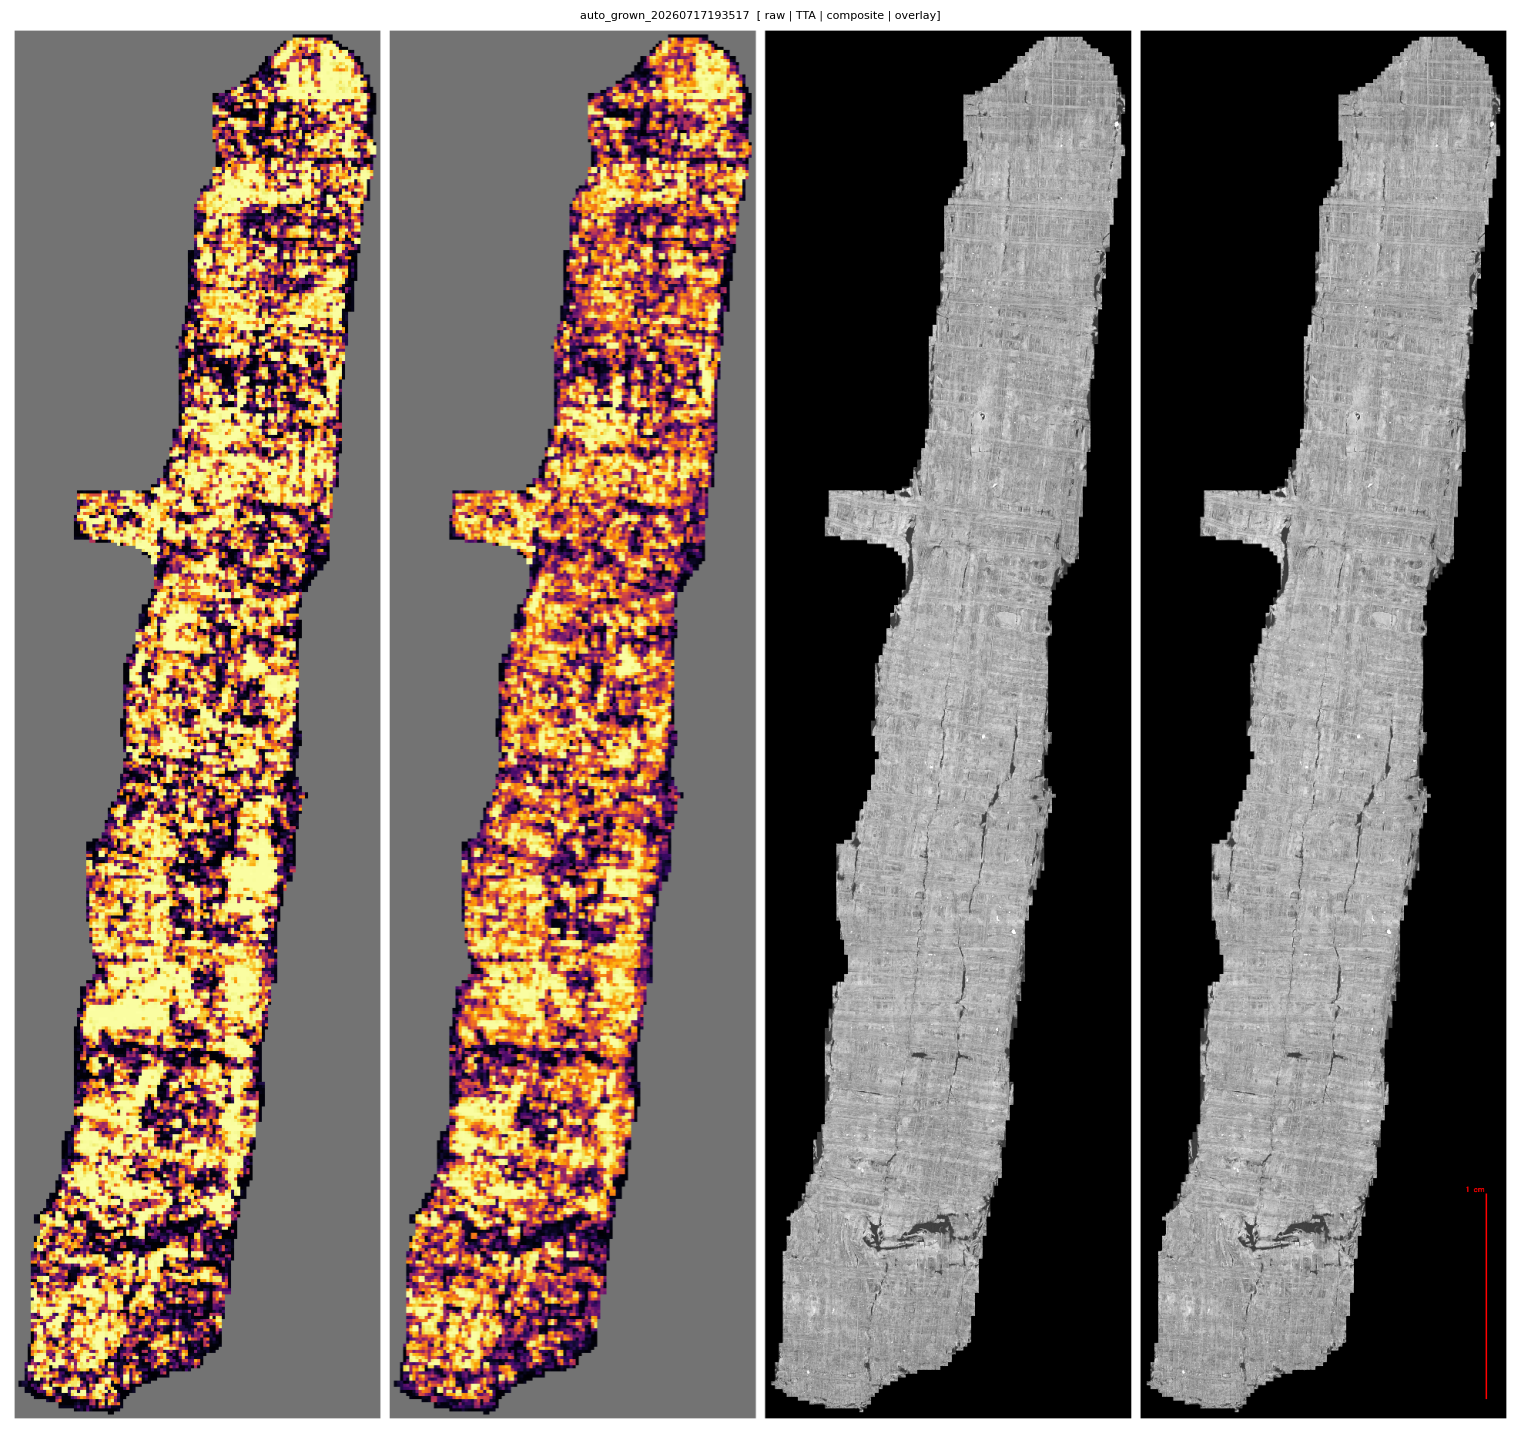

In [ ]:
# --- test fragment 2: PHerc0211 ---
# 11.49cm^2, 7147x1837
NAME = "auto_grown_20260717193517"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)

[predict] reading 21738 tiles in 330 row-strips (Frag_20260719202304)


Predict Frag_20260719202304: 100%|██████████| 85/85 [05:00<00:00,  3.54s/it]


[saved] output\test_visualizations\model_epoch_8\auto_grown_20260719202304.jpg  full size 6672x5377  crop=(5329x1620)  ( raw | TTA | composite | overlay)


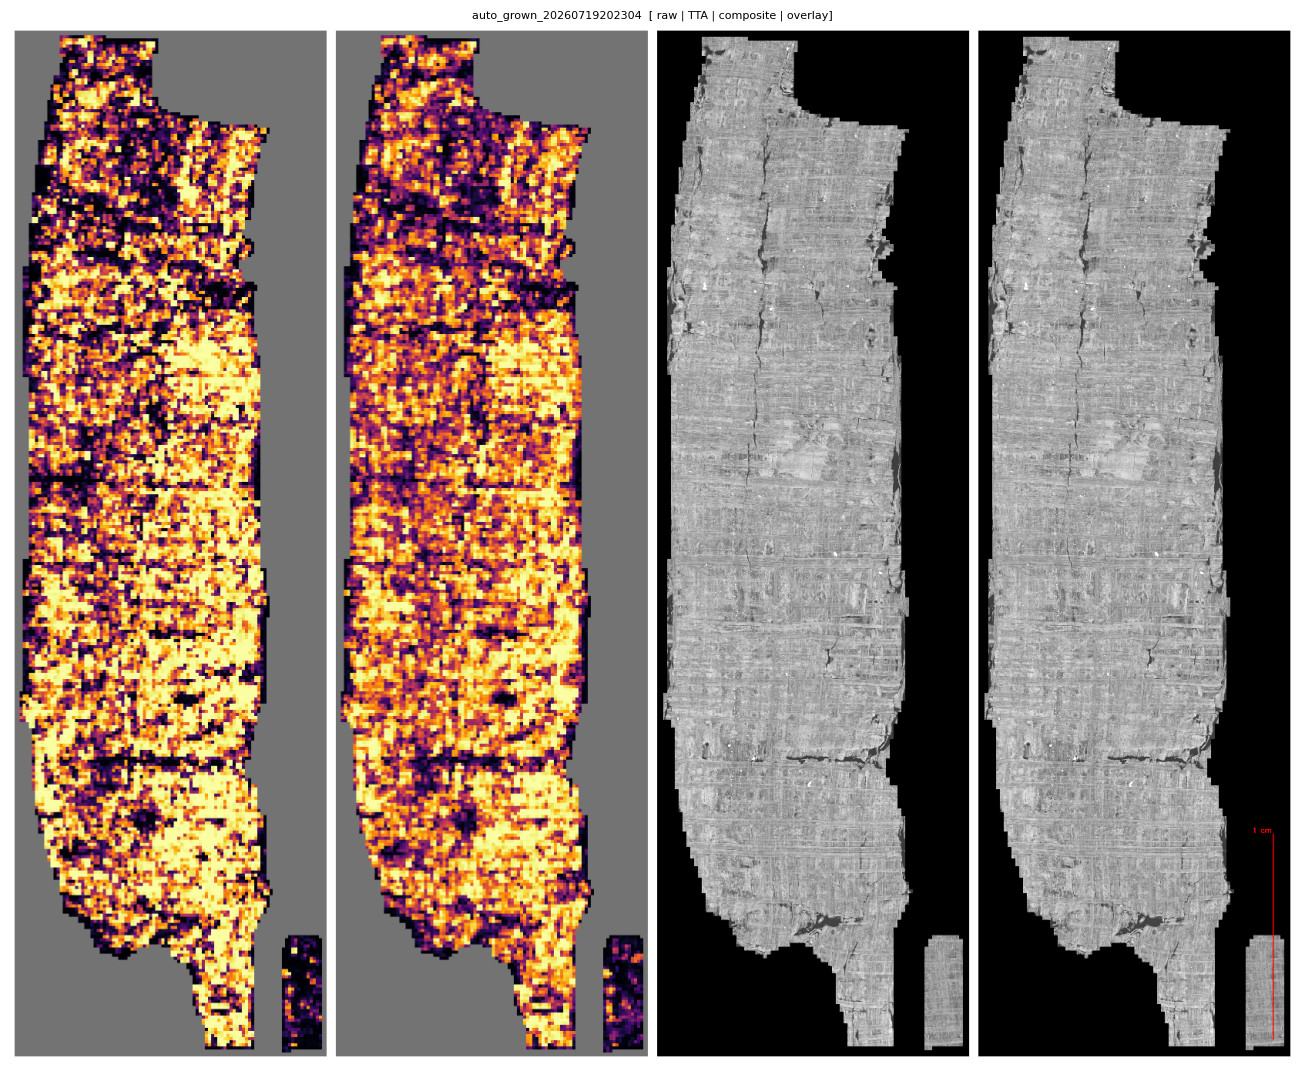

In [ ]:
# --- test fragment 3: PHerc0211 ---
# 10.74cm^2, 5265×1556
NAME = "auto_grown_20260719202304"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)

[predict] reading 47188 tiles in 253 row-strips (Frag_20260720090842)


Predict Frag_20260720090842: 100%|██████████| 185/185 [10:53<00:00,  3.53s/it]


[saved] output\test_visualizations\model_epoch_8\auto_grown_20260720090842.jpg  full size 4567x16588  crop=(4099x4519)  ( raw | TTA | composite | overlay)


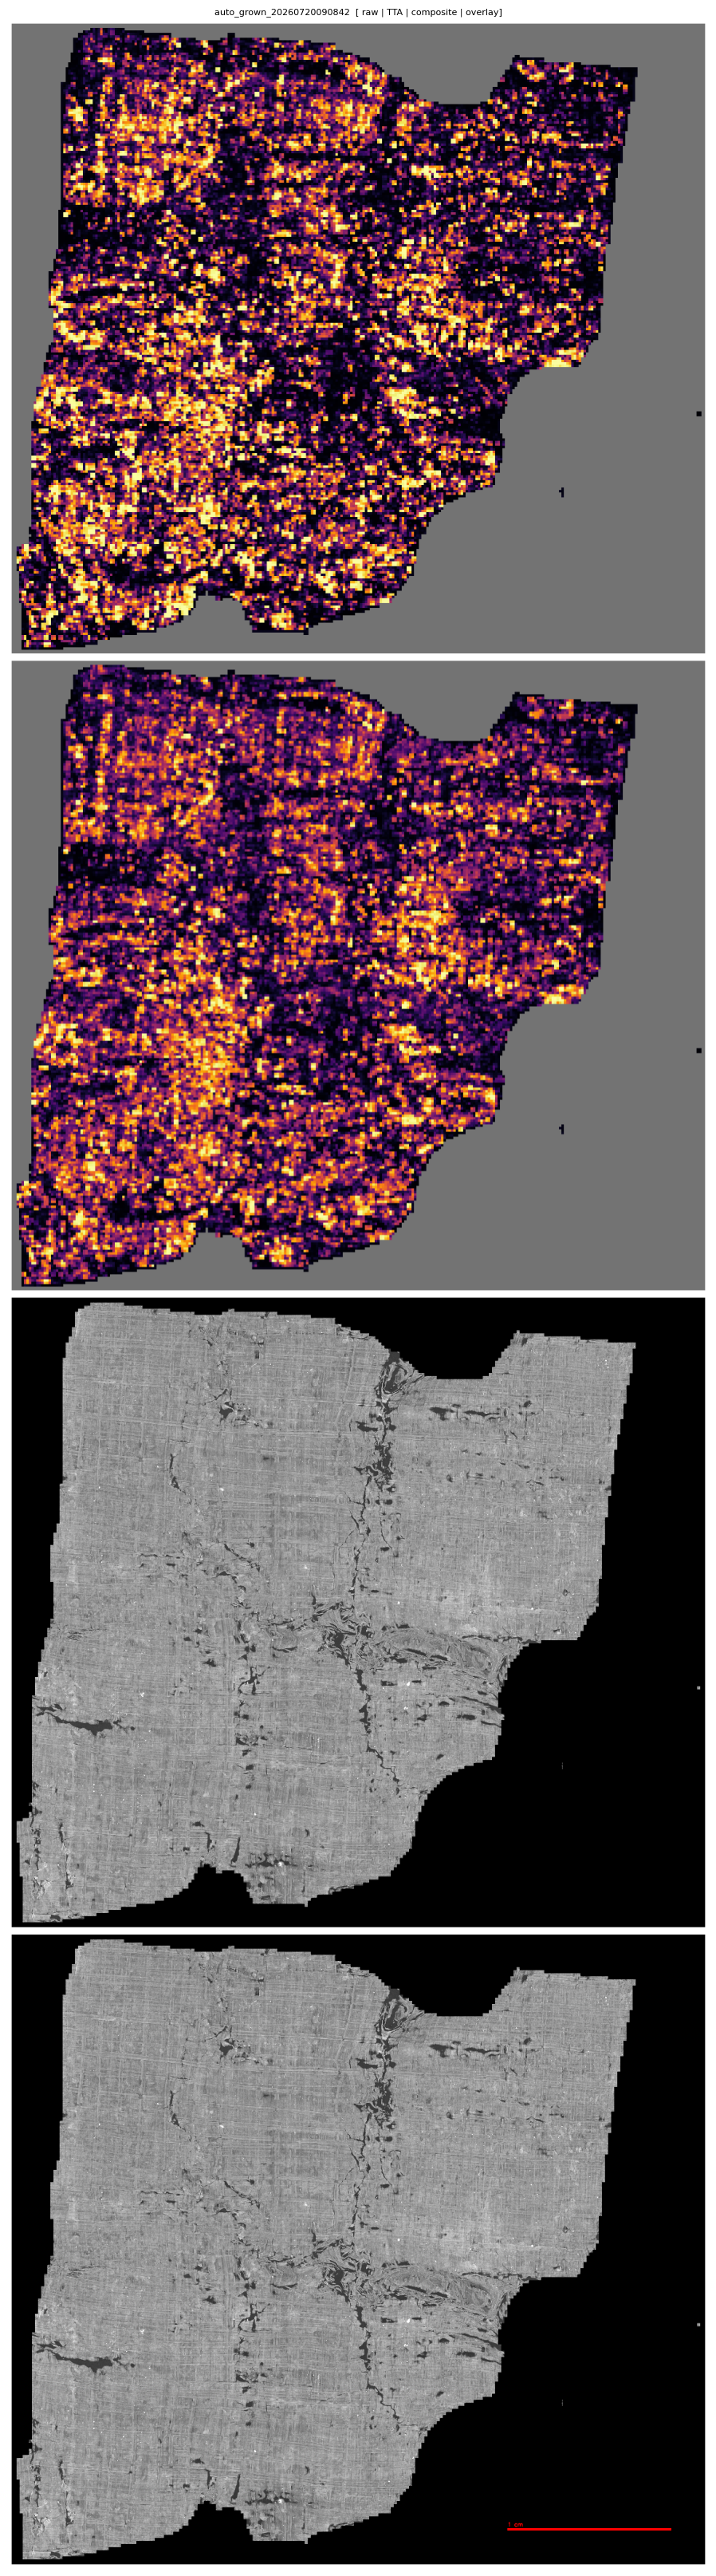

In [ ]:
# --- test fragment 4: PHerc1203 ---
# 7.9cm^2, 4035×4455
NAME = "auto_grown_20260720090842"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)

In [ ]:
# --- test fragment 5: PHerc1447  ---
# 51.27cm^2, 6264×8318 (8.64µm src, upsampled to 9.4µm)
NAME = "auto_grown_20250703034159"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)


[predict] reading 156471 tiles in 393 row-strips (Frag_20250703034159)


Predict Frag_20250703034159:  36%|███▋      | 223/612 [13:11<23:03,  3.56s/it]

In [ ]:
# --- HOLDOUT: w055 (PHerc0139, not in training) — the hallucination sanity check ---
NAME = "w055_holdout_20251226000000"
render_fragment(NAME, FRAGMENTS[NAME], MODEL, C)

[predict] reading 265707 tiles in 476 row-strips (Frag_20251226000000)


Predict Frag_20251226000000: 100%|██████████| 1038/1038 [02:59<00:00,  5.78it/s]


[predict] reading 265707 tiles in 476 row-strips (Frag_20251226000000)


Predict Frag_20251226000000:  77%|███████▋  | 795/1038 [15:52<05:06,  1.26s/it]